## Dataset REVIEWS
[Kaggle Link](https://www.kaggle.com/competitions/184-702-tu-ml-2025-w-reviews/overview)

### Imports

In [28]:
#!pip install openpyxl
import os
import sys
import pandas as pd

# Add the parent directory to sys.path to be able to import own packages from outside the notebooks directory
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# some helper functions (see src directory for details)
from src.utils import *
from src.evaluation import *


In [ ]:
# Load the data and catch a quick glimpse.
curr_dir = os.getcwd()

# Load the given training and test data sets
train_path = os.path.join(curr_dir, '..', 'data', 'reviews/amazon_review_ID.shuf.lrn.csv')
#test_path = os.path.join(curr_dir, '..', 'data', 'reviews/amazon_review_ID.shuf.tes.csv')

train_df = pd.read_csv(train_path)
#final_test_df = pd.read_csv(test_path)

train_df.shape#, test_df.shape

((750, 10002), (750, 10001))

In [88]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif, chi2, SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.cross_decomposition import PLSRegression

In [58]:
target_column = 'Class'
X, y = train_df.drop(columns=[target_column]), train_df[target_column]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
kfold_cv = KFold(n_splits=10, shuffle=True, random_state=42)

TODO FOR DOCS:

- each classifier show multiple results, not just the best  - show results with different  hyper param in each category, do 2-3 runs with best in A, the 3 random in B etc...
- evaluate the performance
    - here use the best modell
    - compare the 4 measures (acc recall prec ..)
    - how can i improve the results? feature selection, some kinda better scaluing?
    - which algo works well for the given dataset, why?
    - Compare holdout to cross-validation, maybe try different train/split sizes
    - run time
- create some kinda table/figure whith all the data collected


KNN

Fast, not much 'learning'

Feature Selection:

SelectKBest preffered, feature selection based on statisctical tests

Pros: Extremely Fast

Cons: It tests each feature in isolation.



--- Starting KNN Search (Strategy: SelectKBest) ---
Fitting 10 folds for each of 20 candidates, totalling 200 fits
KNN search complete.

--- Best KNN Model (SelectKBest) ---
Best Score (CV Accuracy): 0.4583
Best Parameters:
{'knn__n_neighbors': 7, 'selector__k': 200}


c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [2344 2916 3112 3293] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


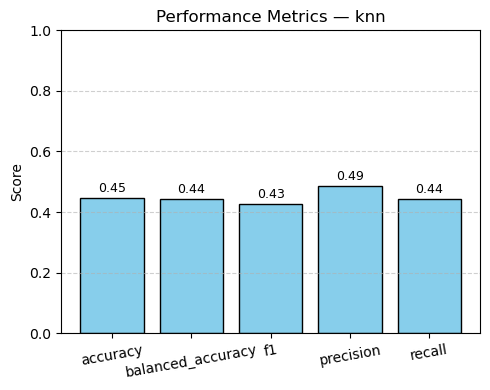

              precision    recall  f1-score   support

     Agresti       0.00      0.00      0.00         3
   Ashbacher       0.50      0.50      0.50         2
       Auken       1.00      0.50      0.67         2
 Blankenship       0.75      1.00      0.86         3
       Brody       0.22      0.67      0.33         3
       Brown       0.25      0.33      0.29         3
    Bukowsky       0.12      0.33      0.18         3
         CFH       1.00      0.67      0.80         3
   Calvinnme       1.00      1.00      1.00         3
     Chachra       0.25      1.00      0.40         4
    Chandler       0.00      0.00      0.00         3
       Chell       0.00      0.00      0.00         4
    Cholette       0.33      0.33      0.33         3
      Comdet       0.50      0.50      0.50         4
        Corn       0.20      0.33      0.25         3
       Cutey       0.00      0.00      0.00         3
    Davisson       0.25      0.50      0.33         4
        Dent       0.67    

c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

In [98]:
pipeline_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(f_classif)), # f_classif acc:  0.4583
    ('knn', KNeighborsClassifier())
])

# 'selector__k': We must reduce *aggressively*.
# 'knn__n_neighbors': We try larger K values to smooth boundaries.
param_grid_knn = {
    'selector__k': [50, 100, 200, 300, 400], # number of features to select
    'knn__n_neighbors': [3, 7, 11, 21]
}
print("\n--- Starting KNN Search (Strategy: SelectKBest) ---")
grid_knn = GridSearchCV(pipeline_knn, param_grid_knn, cv=kfold_cv, scoring='accuracy', n_jobs=-1, verbose=1)
grid_knn.fit(X_train, y_train)
print("KNN search complete.")

print("\n--- Best KNN Model (SelectKBest) ---")
print(f"Best Score (CV Accuracy): {grid_knn.best_score_:.4f}")
print("Best Parameters:")
print(grid_knn.best_params_)

best_knn = grid_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test)

#acc_knn = accuracy_score(y_test, y_pred_knn)
#print(f"KNN Test Accuracy: {acc_knn:.4f}")
evaluation = evaluate_run(name='knn', y_true=y_test, y_pred=y_pred_knn, task_type='classification')
#plot_confusion_matrix(classifier='knn', y_true=y_test, y_pred=y_pred_knn)
plot_metrics(evaluation, figsize=(5,4), x_rotation=10)
print(classification_report(y_test, y_pred_knn))


In [99]:
results_df_knn = pd.DataFrame(grid_knn.cv_results_)

print(results_df_knn)
print(f"\nTotal combinations tested: {len(results_df_knn)}")

    mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
0        0.577116      0.012255         0.175882        0.006873   
1        0.532075      0.052904         0.126739        0.054260   
2        0.538792      0.052407         0.065136        0.015312   
3        0.523011      0.060963         0.054823        0.012687   
4        0.564742      0.087328         0.070405        0.017204   
5        0.520452      0.045903         0.056508        0.012469   
6        0.555979      0.062220         0.055751        0.007973   
7        0.527471      0.046140         0.058287        0.005172   
8        0.530680      0.047538         0.057338        0.009841   
9        0.570579      0.057056         0.067328        0.018149   
10       0.524930      0.046177         0.059166        0.016513   
11       0.539192      0.055968         0.059437        0.015780   
12       0.546383      0.064574         0.060418        0.016865   
13       0.554803      0.074268         0.067074

SVM

Feature selection

SelectKBest(f_classif) -> fast
selector_estimator = LinearSVC (l1, l2) -> too slow, didnt finish


In [ ]:
# --- Algorithm 2: Support Vector Machine (SVM) ---
pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(f_classif)), # f_classif acc: 0.60
    ('svm', SVC(probability=True, random_state=42)) 
])


param_grid_linear = {
    'selector__k': [50, 100,150, 170, 200, 500],
    'svm__kernel': ['linear'],
    'svm__C': [0.01, 0.05, 0.1, 1, 10, 100]
}

param_grid_rbf = {
    'selector__k': [50, 100,150, 170, 200, 500], # RBF is slower, so we test fewer k's
    'svm__kernel': ['rbf'],
    'svm__C': [0.01, 0.05, 0.1, 1, 10, 100],
    'svm__gamma': ['scale', 0.01, 0.05, 0.1] # 'scale' is a good default
}

print("\n--- Starting FINETUNED SVM Search (Linear + RBF) ---")
# We pass the list of grids to the 'param_grid' argument
grid_svm = GridSearchCV(
    pipeline_svm,
    [param_grid_linear, param_grid_rbf],
    cv=kfold_cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_svm.fit(X_train, y_train)

print("\n--- SVM Search Complete ---")
print(f"Best SVM Score (CV Accuracy): {grid_svm.best_score_:.4f}")
print("Best SVM Parameters Found:")
print(grid_svm.best_params_)

best_svm = grid_svm.best_estimator_
y_pred_svm = best_svm.predict(X_test)

evaluation = evaluate_run(name='svm', y_true=y_test, y_pred=y_pred_svm, task_type='classification')
#plot_confusion_matrix(classifier='svm', y_true=y_test, y_pred=y_pred_svm)
plot_metrics(evaluation, figsize=(5,4), x_rotation=10)
print(classification_report(y_test, y_pred_svm))



--- Starting FINETUNED SVM Search (Linear + RBF) ---
Fitting 10 folds for each of 90 candidates, totalling 900 fits

--- SVM Search Complete ---
Best SVM Score (CV Accuracy): 0.6250
Best SVM Parameters Found:
{'selector__k': 150, 'svm__C': 0.05, 'svm__kernel': 'linear'}


c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [2344 2916 3112 3293] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [ ]:
results_df = pd.DataFrame(grid_svm.cv_results_)

print(results_df)
print(f"\nTotal combinations tested: {len(results_df)}")

    mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
17       0.651866      0.075367         0.055603        0.008648   
16       0.690804      0.064575         0.055684        0.006057   
15       0.674609      0.060530         0.055857        0.010938   
13       0.677234      0.050082         0.055499        0.004783   
14       0.675495      0.097028         0.055235        0.005549   
86       0.731896      0.052361         0.054776        0.002933   
82       0.803782      0.047615         0.058860        0.007035   
8        0.578655      0.023147         0.052860        0.005938   
10       0.569064      0.023437         0.054776        0.002977   
9        0.654686      0.055388         0.056493        0.006922   
11       0.676228      0.057558         0.050553        0.002200   
12       0.609312      0.038442         0.055890        0.004162   
87       0.715518      0.053078         0.055782        0.003697   
83       0.704583      0.031454         0.057541

c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


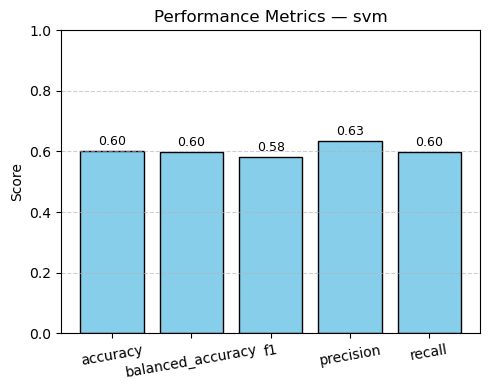

              precision    recall  f1-score   support

     Agresti       0.67      0.67      0.67         3
   Ashbacher       1.00      0.50      0.67         2
       Auken       0.50      0.50      0.50         2
 Blankenship       1.00      1.00      1.00         3
       Brody       0.50      0.67      0.57         3
       Brown       0.33      0.67      0.44         3
    Bukowsky       0.33      0.33      0.33         3
         CFH       1.00      0.67      0.80         3
   Calvinnme       0.00      0.00      0.00         3
     Chachra       0.67      1.00      0.80         4
    Chandler       0.50      0.67      0.57         3
       Chell       0.20      0.25      0.22         4
    Cholette       0.50      0.67      0.57         3
      Comdet       0.50      0.50      0.50         4
        Corn       0.40      0.67      0.50         3
       Cutey       1.00      0.67      0.80         3
    Davisson       0.67      1.00      0.80         4
        Dent       1.00    

c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

In [82]:
best_svm = grid_svm.best_estimator_
y_pred_svm = best_svm.predict(X_test)

evaluation = evaluate_run(name='svm', y_true=y_test, y_pred=y_pred_svm, task_type='classification')
#plot_confusion_matrix(classifier='svm', y_true=y_test, y_pred=y_pred_svm)
plot_metrics(evaluation, figsize=(5,4), x_rotation=10)
print(classification_report(y_test, y_pred_svm))

In [ ]:

# selector_estimator = LinearSVC(penalty='l2', C=0.1, dual=False, random_state=42, max_iter=2000)
#  # as an experiment i let it run for 95 mins, no result -> this might be good/precise but it takes too long
#  # even with SelectFromModel+l2 it takes a long time
# pipeline_svm_sfm = Pipeline([
#     ('scaler', StandardScaler()),
#     ('selector', SelectFromModel(selector_estimator)),
#     ('svm', LinearSVC(dual=False, random_state=42, max_iter=2000))
# ])


# param_grid_sfm = {
#     'selector__estimator__C': [0.01, 0.1, 1.0], # Tunes the selector's 'C'
#     'selector__threshold': ['mean', '1.25*mean', 'median'], # Tunes the cutoff
#     'svm__C': [0.01, 0.05, 0.1] # Tunes the final classifier's 'C'
# }

# print("\n--- Starting SVM Search (Strategy: SelectFromModel) ---")
# grid_svm_sfm = RandomizedSearchCV(  # option for a 'good enough' result: RandomizedSearchCV
#     pipeline_svm_sfm,
#     param_grid_sfm,
#     n_iter=10,
#     cv=kfold_cv,
#     scoring='accuracy',
#     n_jobs=-1,
#     verbose=1
# )
# grid_svm_sfm.fit(X_train, y_train)

# # -----------------------------------------------------------------
# # 5. Review and Evaluate
# # -----------------------------------------------------------------
# print("\n--- SVM (SelectFromModel) Search Complete ---")
# print(f"Best SVM Score (CV Accuracy): {grid_svm_sfm.best_score_:.4f}")
# print("Best SVM Parameters Found:")
# print(grid_svm_sfm.best_params_)

# best_svm_model = grid_svm_sfm.best_estimator_
# y_pred_svm = best_svm_model.predict(X_test)
# acc_svm = accuracy_score(y_test, y_pred_svm)

# print(f"\nFinal SVM Test Accuracy: {acc_svm:.4f}")
# print(classification_report(y_test, y_pred_svm))


--- Starting SVM Search (Strategy: SelectFromModel) ---
Fitting 10 folds for each of 10 candidates, totalling 100 fits


KeyboardInterrupt: 

wanted to do Recursive Feature Elimination, but realized that would take forever in case of 10k features -> check if there is threshold setting for this

Decision Tree

not good for many features low sample size -> overfit on high dimensional data

--- Starting Decision Tree Search ---
Decision Tree search complete.

--- Best Decision Tree Model ---
Best Score (CV Accuracy): 0.3983
Best Parameters:
{'dt__criterion': 'gini', 'dt__max_depth': None, 'dt__min_samples_leaf': 5, 'scaler': StandardScaler(), 'selector__k': 150}
DT Test Accuracy:  0.3467


c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [2344 2916 3112 3293] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


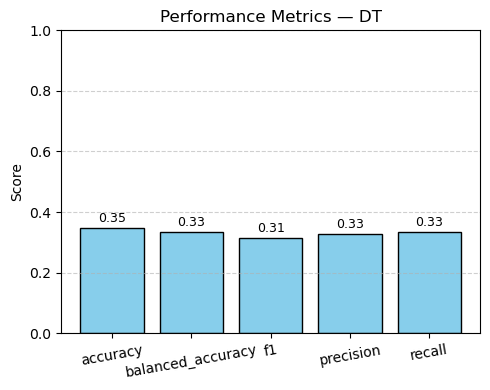

              precision    recall  f1-score   support

     Agresti       0.00      0.00      0.00         3
   Ashbacher       0.00      0.00      0.00         2
       Auken       0.00      0.00      0.00         2
 Blankenship       1.00      1.00      1.00         3
       Brody       0.00      0.00      0.00         3
       Brown       0.00      0.00      0.00         3
    Bukowsky       0.00      0.00      0.00         3
         CFH       0.14      0.33      0.20         3
   Calvinnme       0.00      0.00      0.00         3
     Chachra       0.60      0.75      0.67         4
    Chandler       1.00      0.33      0.50         3
       Chell       0.50      0.75      0.60         4
    Cholette       0.00      0.00      0.00         3
      Comdet       0.00      0.00      0.00         4
        Corn       0.00      0.00      0.00         3
       Cutey       0.00      0.00      0.00         3
    Davisson       0.20      0.25      0.22         4
        Dent       0.50    

c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lenar\anaconda3\envs\Machinelearning\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.c

In [ ]:
pipeline_dt = Pipeline([
    ('scaler', 'passthrough'),
    ('selector', SelectKBest(f_classif)),
    ('dt', DecisionTreeClassifier(random_state=42))
])
param_grid_dt = {
    'scaler': [StandardScaler(), 'passthrough'], # 'passthrough' means "do nothing"
    'selector__k': [50, 75, 100, 125, 150, 200],
    'dt__max_depth': [1, 3, 5, 10,  None],
    'dt__criterion': ['gini', 'entropy'],
    'dt__min_samples_leaf': [3, 5, 10, 20]
}
print("--- Starting Decision Tree Search ---")
grid_dt = GridSearchCV(pipeline_dt, param_grid_dt, cv=kfold_cv, scoring='accuracy', n_jobs=-1)
grid_dt.fit(X_train, y_train)
print("Decision Tree search complete.")

print("\n--- Best Decision Tree Model ---")
print(f"Best Score (CV Accuracy): {grid_dt.best_score_:.4f}")
print("Best Parameters:")
print(grid_dt.best_params_)

best_dt = grid_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)
print(f"DT Test Accuracy:  {acc_dt:.4f}")

evaluation = evaluate_run(name='DT', y_true=y_test, y_pred=y_pred_dt, task_type='classification')
#plot_confusion_matrix(classifier='svm', y_true=y_test, y_pred=y_pred_svm)
plot_metrics(evaluation, figsize=(5,4), x_rotation=10)
print(classification_report(y_test, y_pred_dt))

In [96]:
results_df_dt = pd.DataFrame(grid_dt.cv_results_)

print(results_df_dt)
print(f"\nTotal combinations tested: {len(results_df_dt)}")

     mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
0         0.551293      0.018533         0.050266        0.003625   
1         0.514330      0.040547         0.048579        0.005006   
2         0.558373      0.019826         0.050252        0.007317   
3         0.539857      0.046429         0.051538        0.007570   
4         0.539342      0.036432         0.051709        0.004654   
5         0.539400      0.036665         0.050713        0.006408   
6         0.539403      0.035205         0.051055        0.007471   
7         0.563028      0.051244         0.051267        0.004807   
8         0.259796      0.024818         0.043472        0.004692   
9         0.261830      0.029774         0.043961        0.003793   
10        0.255653      0.023762         0.045093        0.004193   
11        0.263225      0.024572         0.042992        0.003574   
12        0.264022      0.040678         0.047070        0.007375   
13        0.263437      0.039790  